In [1]:
# import library

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### pra-proses

In [6]:
#Inisialisasi variabel
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/inpi.xlsx')
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])

#Sinkronisasi Waktu
bl = pd.to_datetime(wk).dt.tz_localize(None)
bl = np.array(bl).astype('datetime64[ms]')

#State Waktu yang Ideal
t = np.arange(datetime(2026,5,4,16,6), datetime(2026,5,11,14,27), timedelta(minutes=1))
t = t.astype('datetime64[ms]')

#Cek Timestamp per 1 Menit
cek = np.isin(bl,t)

t_awz = []
ta_awz = []
rh_awz = []
for i in range(len(bl)):
    if(cek[i].all()==True):
        t_awz.append(bl[i])
        ta_awz.append(ta[i])
        rh_awz.append(rh[i])
t_awz = np.array(t_awz)

#Cek Gap Timestamp
waktu = np.isin(t,t_awz)

#Input Missing Data
for i in range(len(t)):
    if(waktu[i].all()==False):
        ta_awz.insert(i,float("nan"))
        rh_awz.insert(i,float("nan"))
        
taz = np.array(ta_awz)
rhz = np.array(rh_awz)

#Deteksi outlier

#QC Temperatur
for i in range(len(taz)-1):
    if(((taz[i]<5)or(taz[i]>45))or(taz[i+1]-taz[i]>3)):
        taz[i]=float("nan")

#QC Humidity
for i in range(len(rhz)-1):
    if(((rhz[i]<30)or(rhz[i]>100))or(rhz[i+1]-rhz[i]>15)):
        rhz[i]=float("nan")

taz = np.nan_to_num(taz,nan=30)
rhz = np.nan_to_num(rhz,nan=60)

#SIMPAN FILE
df1 = pd.DataFrame(t.tolist())
df2 = pd.DataFrame(taz)
df3 = pd.DataFrame(rhz)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','TA','RH']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx", index=False)

In [7]:
# Cek data yang hilang saat sinkronisasi timestamp
print(f'Data awal        : {len(bl)}')
print(f'Data setelah cek : {len(t_awz)}')
print(f'Data hilang      : {len(bl) - len(t_awz)}')

# Lihat timestamp mana yang tidak cocok dengan acuan
bl_set = set(bl.tolist())
t_set  = set(t.tolist())

# Timestamp di data tapi tidak ada di acuan (dibuang)
tidak_cocok = bl_set - t_set
print(f'\nTimestamp di data tapi tidak ada di acuan waktu:')
for ts in sorted(tidak_cocok):
    print(ts)

# Timestamp di acuan tapi tidak ada di data (missing)
missing = t_set - bl_set
print(f'\nTimestamp yang missing (diisi NaN):')
for ts in sorted(missing):
    print(ts)

Data awal        : 9982
Data setelah cek : 9981
Data hilang      : 1

Timestamp di data tapi tidak ada di acuan waktu:
2026-05-11 14:27:00

Timestamp yang missing (diisi NaN):


### exploratory data analysis (eda)

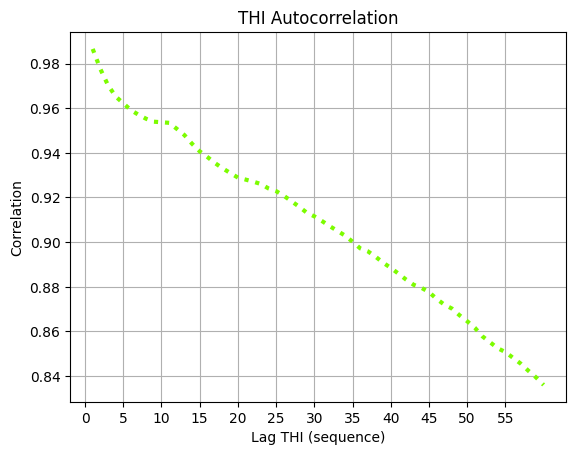

In [ ]:
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi3.xlsx')
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)


r_model = LinearRegression()
corr_thi = []
for i in range(0,60,1):
    sumbu_x = thi[:(-1*(i+1))]
    sumbu_y = thi[(i+1):]
    r_model.fit(sumbu_x,sumbu_y)
    r_squared = r_model.score(sumbu_x,sumbu_y)
    r_corr = math.sqrt(r_squared)
    corr_thi.append(r_corr)
    
corr_thi = np.array(corr_thi)
interval = np.arange(1,61,1)


plt.plot(interval,corr_thi,ls='dotted', lw=3, color='lawngreen')
plt.title('THI Autocorrelation',fontsize=12)
plt.xlabel('Lag THI (sequence)')
plt.xticks(np.arange(0, 60, step=5))
plt.ylabel('Correlation')
plt.grid()
plt.show()

## LSTM

### **10 menit**

Epoch 1/50


C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1365
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0109
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0086
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033


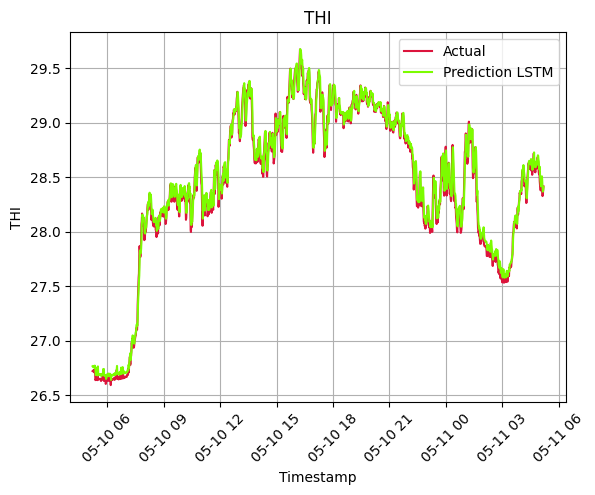

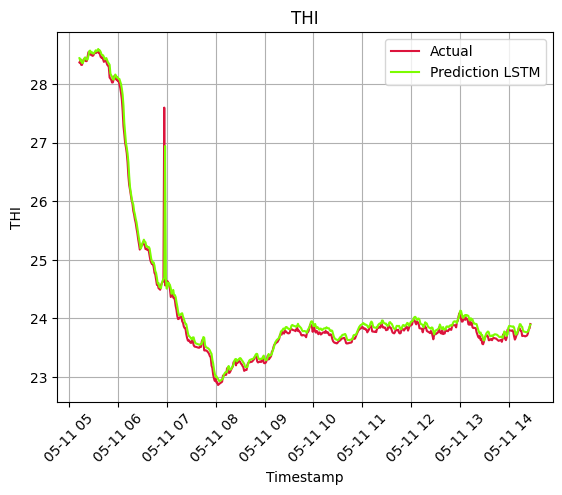

In [ ]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 10 MENIT KE DEPAN
ia1 = thi[9:-1]
ia2 = thi[8:-2]
ia3 = thi[7:-3]
ia4 = thi[6:-4]
ia5 = thi[5:-5]
ia6 = thi[4:-6]
ia7 = thi[3:-7]
ia8 = thi[2:-8]
ia9 = thi[1:-9]
ia10 = thi[:-10]

input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[10:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[10:]  # ← PERBAIKAN: samakan panjang wk dengan output
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#LSTM
inp_train = np.reshape(inp_train,(len(inp_train),10,1))
classifier = Sequential()
classifier.add(LSTM(40, input_shape=(10,1), activation="relu"))
classifier.add(Dense(40, activation="relu"))
classifier.add(Dense(units=1, kernel_initializer="normal", activation="linear"))
classifier.compile(optimizer="adam", loss="mean_squared_error")
history = classifier.fit(inp_train, out_train, batch_size=32, epochs=50)

#Simpan Model
import joblib
joblib.dump(classifier, 'lstm_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)
df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_Loss_10.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI LSTM
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr LSTM:\n")
print(r_corr)

mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 
start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction LSTM')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.grid()
    plt.legend()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi LSTM']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_THI_10.xlsx")

#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_LSTM_THI_10.xlsx")

### **30 menit**

C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1640
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0624
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0616
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0583
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0568
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0561
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0549
Epoch 8/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0542
Epoch 9/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0535
Epoch 10/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0526
Epoch 11/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0519
Epoch 12/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0509
Epoch 13/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0523
Epoch 14/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0513
Epoch 15/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

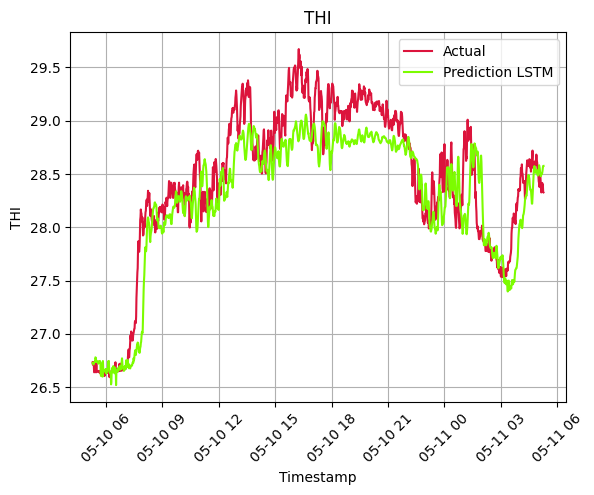

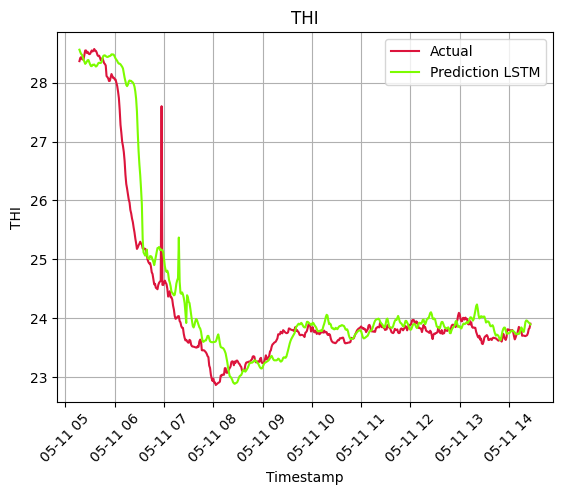

In [ ]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 30 MENIT KE DEPAN
ia1 = thi[9:-21]
ia2 = thi[8:-22]
ia3 = thi[7:-23]
ia4 = thi[6:-24]
ia5 = thi[5:-25]
ia6 = thi[4:-26]
ia7 = thi[3:-27]
ia8 = thi[2:-28]
ia9 = thi[1:-29]
ia10 = thi[:-30]

input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[30:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[30:]  # ← PERBAIKAN: samakan panjang wk dengan output
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#LSTM
inp_train = np.reshape(inp_train,(len(inp_train),10,1))
classifier = Sequential()
classifier.add(LSTM(40, input_shape=(10,1), activation="relu"))
classifier.add(Dense(40, activation="relu"))
classifier.add(Dense(units=1, kernel_initializer="normal", activation="linear"))
classifier.compile(optimizer="adam", loss="mean_squared_error")
history = classifier.fit(inp_train, out_train, batch_size=32, epochs=50)

#Simpan Model
import joblib
joblib.dump(classifier, 'lstm_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)
df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_Loss_30.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI LSTM
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr LSTM:\n")
print(r_corr)

mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 
start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction LSTM')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.grid()
    plt.legend()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi LSTM']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_THI_30.xlsx")

#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_LSTM_THI_30.xlsx")

### **60 menit**

C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2251
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1338
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1323
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1311
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1296
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1296
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1275
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1264
Epoch 9/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1247
Epoch 10/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1237
Epoch 11/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1214
Epoch 12/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1220
Epoch 13/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1214
Epoch 14/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1191
Epoch 15/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

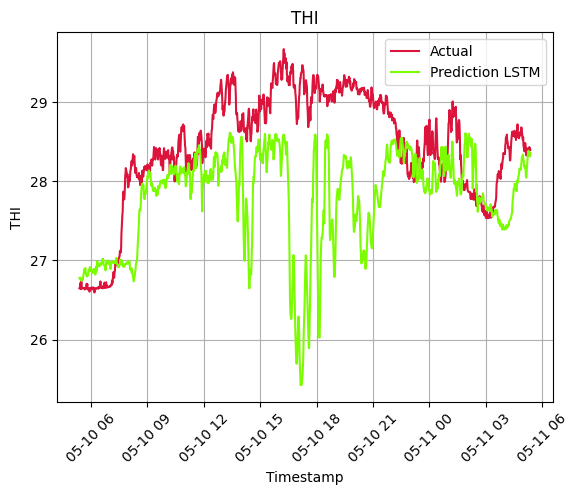

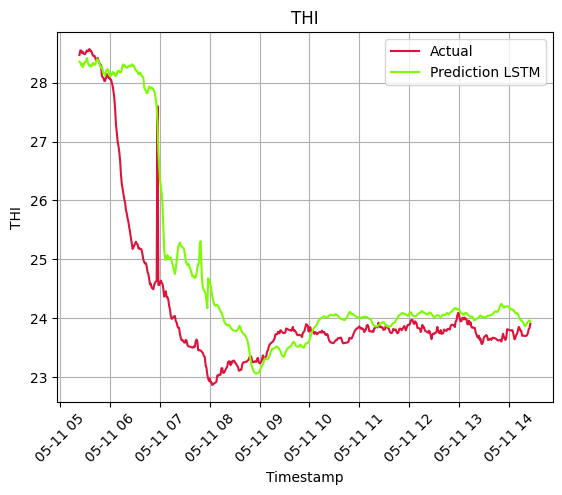

In [11]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 60 MENIT KE DEPAN
ia1 = thi[9:-51]
ia2 = thi[8:-52]
ia3 = thi[7:-53]
ia4 = thi[6:-54]
ia5 = thi[5:-55]
ia6 = thi[4:-56]
ia7 = thi[3:-57]
ia8 = thi[2:-58]
ia9 = thi[1:-59]
ia10 = thi[:-60]

input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[60:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[60:]  # ← PERBAIKAN: samakan panjang wk dengan output
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#LSTM
inp_train = np.reshape(inp_train,(len(inp_train),10,1))
classifier = Sequential()
classifier.add(LSTM(40, input_shape=(10,1), activation="relu"))
classifier.add(Dense(40, activation="relu"))
classifier.add(Dense(units=1, kernel_initializer="normal", activation="linear"))
classifier.compile(optimizer="adam", loss="mean_squared_error")
history = classifier.fit(inp_train, out_train, batch_size=32, epochs=50)

#Simpan Model
import joblib
joblib.dump(classifier, 'lstm_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)
df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_Loss_60.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI LSTM
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr LSTM:\n")
print(r_corr)

mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 
start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction LSTM')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.grid()
    plt.legend()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi LSTM']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/LSTM_THI_60.xlsx")

#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_LSTM_THI_60.xlsx")

## GRU

### **10 menit**

Epoch 1/50


C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1387
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0125
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0093
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0075
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032
Epoch 15/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032


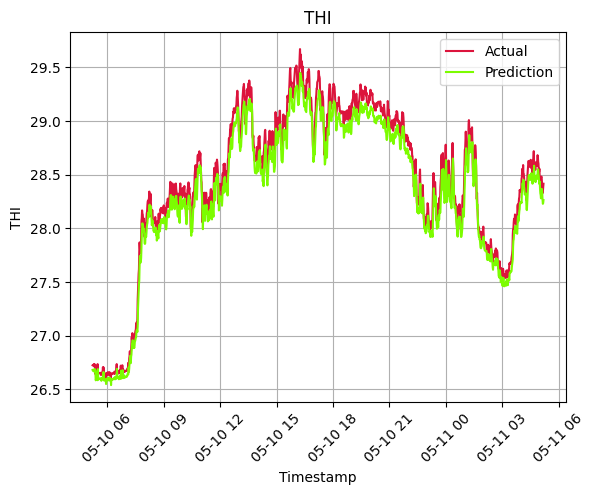

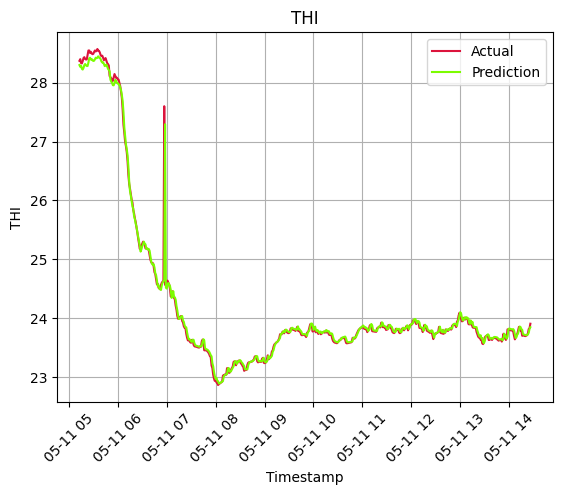

In [13]:

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

#import library-library machine learning
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
    
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 10 MENIT KE DEPAN
#Deklarasi Input (10 data sebelumnya) 
ia1 = thi[9:-1]
ia2 = thi[8:-2]
ia3 = thi[7:-3]
ia4 = thi[6:-4]
ia5 = thi[5:-5]
ia6 = thi[4:-6]
ia7 = thi[3:-7]
ia8 = thi[2:-8]
ia9 = thi[1:-9]
ia10 = thi[:-10]

#menggabungkan variabel-variabel input 
input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[10:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[10:]
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#GRU (memasukkan data training ke model)
inp_train = np.reshape(inp_train,(len(inp_train),10,1))

#Desain Struktur GRU : 2 hidden layer, masing-masing layer 40 neuron, fungsi aktivasi tanh, batch size 32, epoch 100
classifier = Sequential()
classifier.add(GRU(
    40,
    input_shape=(10,1),
    activation="relu",
    ))
classifier.add(Dense(
    40,
    activation="relu",
    ))
classifier.add(Dense(
    units=1,
    kernel_initializer="normal",
    activation="linear"
    ))
classifier.compile(
    optimizer="adam",
    loss="mean_squared_error",
    )
history = classifier.fit(
    inp_train,
    out_train,
    batch_size=32,
    epochs=50
    )

#Simpan Model
import joblib
joblib.dump(classifier, 'gru_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)

df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_Loss_10.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI GRU

#r-squared
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr GRU:\n")
print(r_corr)

#rmse
mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

#mape
mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 

start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.legend()
    plt.grid()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi GRU']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_THI_10.xlsx")


#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_GRU_THI_10.xlsx")

### **30 menit**

Epoch 1/50


C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1934
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0648
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0629
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0595
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0580
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0559
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0546
Epoch 8/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0544
Epoch 9/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0528
Epoch 10/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0521
Epoch 11/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0519
Epoch 12/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0504
Epoch 13/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0522
Epoch 14/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0500
Epoch 15/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0499


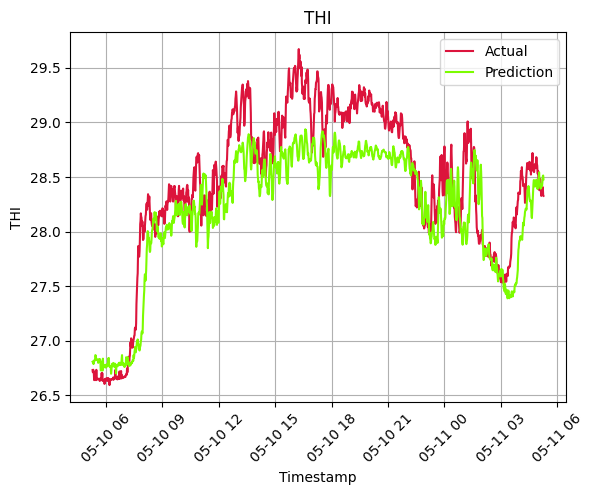

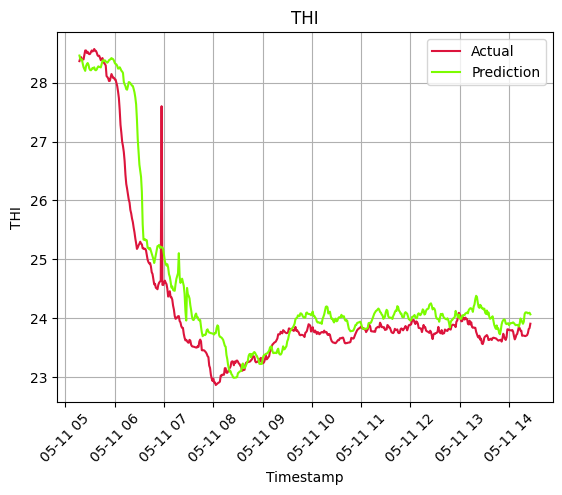

In [14]:

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

#import library-library machine learning
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
    
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 30 MENIT KE DEPAN
#Deklarasi Input (10 data sebelumnya) 
ia1 = thi[9:-21]
ia2 = thi[8:-22]
ia3 = thi[7:-23]
ia4 = thi[6:-24]
ia5 = thi[5:-25]
ia6 = thi[4:-26]
ia7 = thi[3:-27]
ia8 = thi[2:-28]
ia9 = thi[1:-29]
ia10 = thi[:-30]

#menggabungkan variabel-variabel input 
input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[30:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[30:]
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#GRU (memasukkan data training ke model)
inp_train = np.reshape(inp_train,(len(inp_train),10,1))

#Desain Struktur GRU : 2 hidden layer, masing-masing layer 40 neuron, fungsi aktivasi tanh, batch size 32, epoch 100
classifier = Sequential()
classifier.add(GRU(
    40,
    input_shape=(10,1),
    activation="relu",
    ))
classifier.add(Dense(
    40,
    activation="relu",
    ))
classifier.add(Dense(
    units=1,
    kernel_initializer="normal",
    activation="linear"
    ))
classifier.compile(
    optimizer="adam",
    loss="mean_squared_error",
    )
history = classifier.fit(
    inp_train,
    out_train,
    batch_size=32,
    epochs=50
    )

#Simpan Model
import joblib
joblib.dump(classifier, 'gru_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)

df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_Loss_30.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI GRU

#r-squared
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr GRU:\n")
print(r_corr)

#rmse
mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

#mape
mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 

start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.legend()
    plt.grid()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi GRU']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_THI_30.xlsx")


#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_GRU_THI_30.xlsx")

### **60 menit**

Epoch 1/50


C:\Users\aprim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2396
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1366
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1341
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1317
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1299
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1275
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1257
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1255
Epoch 9/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1234
Epoch 10/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1215
Epoch 11/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1205
Epoch 12/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1188
Epoch 13/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1179
Epoch 14/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1169
Epoch 15/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1161


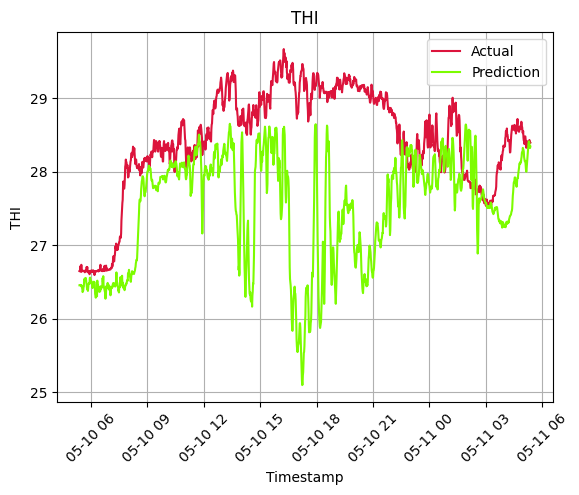

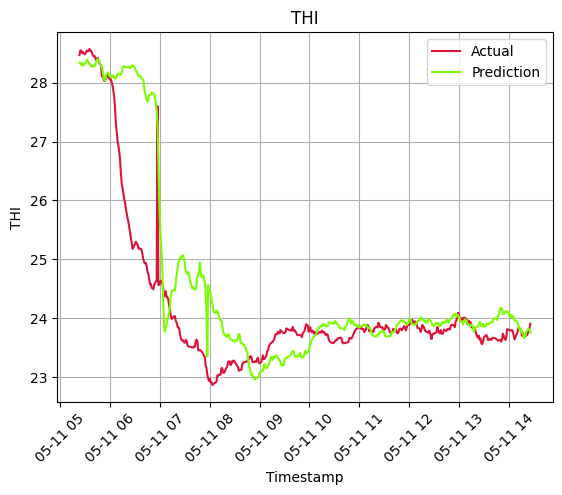

In [16]:

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

#import library-library machine learning
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
from sklearn.linear_model import LinearRegression

#Deklarasi Raw Data
    
aws = pd.read_excel('D:/SEMESTER 6/magang things/DATA/inpi3/QC_inpi.xlsx')

#Deklarasi Data TA dan RH
wk = aws['Waktu']
ta = np.array(aws['TA'])
rh = np.array(aws['RH'])
thi = 0.8*ta + ((ta*rh)/500) 
thi = thi.reshape(-1,1)

#PREDIKSI 60 MENIT KE DEPAN
#Deklarasi Input (10 data sebelumnya) 
ia1 = thi[9:-51]
ia2 = thi[8:-52]
ia3 = thi[7:-53]
ia4 = thi[6:-54]
ia5 = thi[5:-55]
ia6 = thi[4:-56]
ia7 = thi[3:-57]
ia8 = thi[2:-58]
ia9 = thi[1:-59]
ia10 = thi[:-60]

#menggabungkan variabel-variabel input 
input = np.concatenate([ia1,ia2,ia3,ia4,ia5,ia6,ia7,ia8,ia9,ia10])
input = np.reshape(input,(10,int(len(input)/10)))
input = input.T

#Deklarasi Output
oa = thi[60:]
output = oa

#transformasi data input dan output
sc = StandardScaler()
input_fit = sc.fit(input)
input = input_fit.transform(input)
output_fit = sc.fit(output)
output = output_fit.transform(output)

#segmentasi data (80% training, 20% validasi)
wk_out = wk[60:]
t_train = wk_out[:int(0.8*len(wk_out))]
t_test = wk_out[int(0.8*len(wk_out)):]

inp_train = input[:int(0.8*len(input))]
out_train = output[:int(0.8*len(output))]

inp_test = input[int(0.8*len(input)):]
out_test = output[int(0.8*len(output)):]

#GRU (memasukkan data training ke model)
inp_train = np.reshape(inp_train,(len(inp_train),10,1))

#Desain Struktur GRU : 2 hidden layer, masing-masing layer 40 neuron, fungsi aktivasi tanh, batch size 32, epoch 100
classifier = Sequential()
classifier.add(GRU(
    40,
    input_shape=(10,1),
    activation="relu",
    ))
classifier.add(Dense(
    40,
    activation="relu",
    ))
classifier.add(Dense(
    units=1,
    kernel_initializer="normal",
    activation="linear"
    ))
classifier.compile(
    optimizer="adam",
    loss="mean_squared_error",
    )
history = classifier.fit(
    inp_train,
    out_train,
    batch_size=32,
    epochs=50
    )

#Simpan Model
import joblib
joblib.dump(classifier, 'gru_thi.joblib')

loss_train = np.array(history.history['loss'])
epochs = np.arange(0,50)

df1 = pd.DataFrame(epochs)
df2 = pd.DataFrame(loss_train)
df = pd.concat([df1,df2],axis=1)
df.columns = ['Epochs','Loss']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_Loss_60.xlsx")

#mengembalikan transformasi output kembali ke data awal
inp_test = np.reshape(inp_test,(len(inp_test),10,1))
out_pred = classifier.predict(inp_test)
out_test = output_fit.inverse_transform(out_test)
out_pred = output_fit.inverse_transform(out_pred)

#VALIDASI GRU

#r-squared
r_model = LinearRegression()
r_model.fit(out_test, out_pred)
r_squared = r_model.score(out_test, out_pred)
r_corr = math.sqrt(r_squared)
print("R-Corr GRU:\n")
print(r_corr)

#rmse
mses = np.square(out_test - out_pred).mean()   
rmses = math.sqrt(mses)
print("RMSE:\n")
print(rmses)

#mape
mape = np.mean(100 * (np.abs((out_test - out_pred)/out_test)))
print("MAPE:\n")
print(mape)

# PLOT DATA
start = np.arange(1,len(t_test),1440)
tamb = np.ravel(np.full((1,len(start)),1440))
final = start+tamb 

start=start[:50]
final=final[:50]

for i in range(len(start)):
    plt.plot(t_test[start[i]:final[i]],out_test[start[i]:final[i]],'crimson',label='Actual')
    plt.plot(t_test[start[i]:final[i]],out_pred[start[i]:final[i]],'lawngreen',label='Prediction')
    plt.title('THI',fontsize=12)
    plt.xticks(rotation=45)
    plt.xlabel('Timestamp')
    plt.ylabel('THI')
    plt.legend()
    plt.grid()
    plt.show()

#Simpan Hasil Prediksi
df1 = pd.DataFrame(t_test)
df2 = pd.DataFrame(out_test)
df3 = pd.DataFrame(out_pred)
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['Waktu','Aktual','Prediksi GRU']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/GRU_THI_60.xlsx")


#Simpan Performa
df1 = pd.DataFrame([r_corr])
df2 = pd.DataFrame([rmses])
df3 = pd.DataFrame([mape])
df = pd.concat([df1,df2,df3],axis=1)
df.columns = ['R','RMSE','MAPE']
df.to_excel(excel_writer = "D:/SEMESTER 6/magang things/DATA/inpi3/Performa_GRU_THI_60.xlsx")

## PERBANDINGAN

**inisiasi**

In [18]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

path = 'D:/SEMESTER 6/magang things/DATA/inpi3/'

lstm10 = pd.read_excel(path + 'Performa_LSTM_THI_10.xlsx')
lstm30 = pd.read_excel(path + 'Performa_LSTM_THI_30.xlsx')
lstm60 = pd.read_excel(path + 'Performa_LSTM_THI_60.xlsx')
gru10  = pd.read_excel(path + 'Performa_GRU_THI_10.xlsx')
gru30  = pd.read_excel(path + 'Performa_GRU_THI_30.xlsx')
gru60  = pd.read_excel(path + 'Performa_GRU_THI_60.xlsx')

labels    = ['10 mnt', '30 mnt', '60 mnt']
R_lstm    = [lstm10['R'].values[0],    lstm30['R'].values[0],    lstm60['R'].values[0]]
R_gru     = [gru10['R'].values[0],     gru30['R'].values[0],     gru60['R'].values[0]]
RMSE_lstm = [lstm10['RMSE'].values[0], lstm30['RMSE'].values[0], lstm60['RMSE'].values[0]]
RMSE_gru  = [gru10['RMSE'].values[0],  gru30['RMSE'].values[0],  gru60['RMSE'].values[0]]
MAPE_lstm = [lstm10['MAPE'].values[0], lstm30['MAPE'].values[0], lstm60['MAPE'].values[0]]
MAPE_gru  = [gru10['MAPE'].values[0],  gru30['MAPE'].values[0],  gru60['MAPE'].values[0]]

BG     = '#0D1117'
CARD   = '#161B22'
LSTM_C = "#735895"
GRU_C  = "#507E56"
TEXT   = '#E6EDF3'
MUTED  = '#8B949E'
ACCENT = "#F96191"
x      = np.arange(len(labels))
width  = 0.32

lstm_patch = mpatches.Patch(color=LSTM_C, label='LSTM')
gru_patch  = mpatches.Patch(color=GRU_C,  label='GRU')

plt.rcParams.update({
    'font.family'      : 'monospace',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
})


### **bar chart performa**

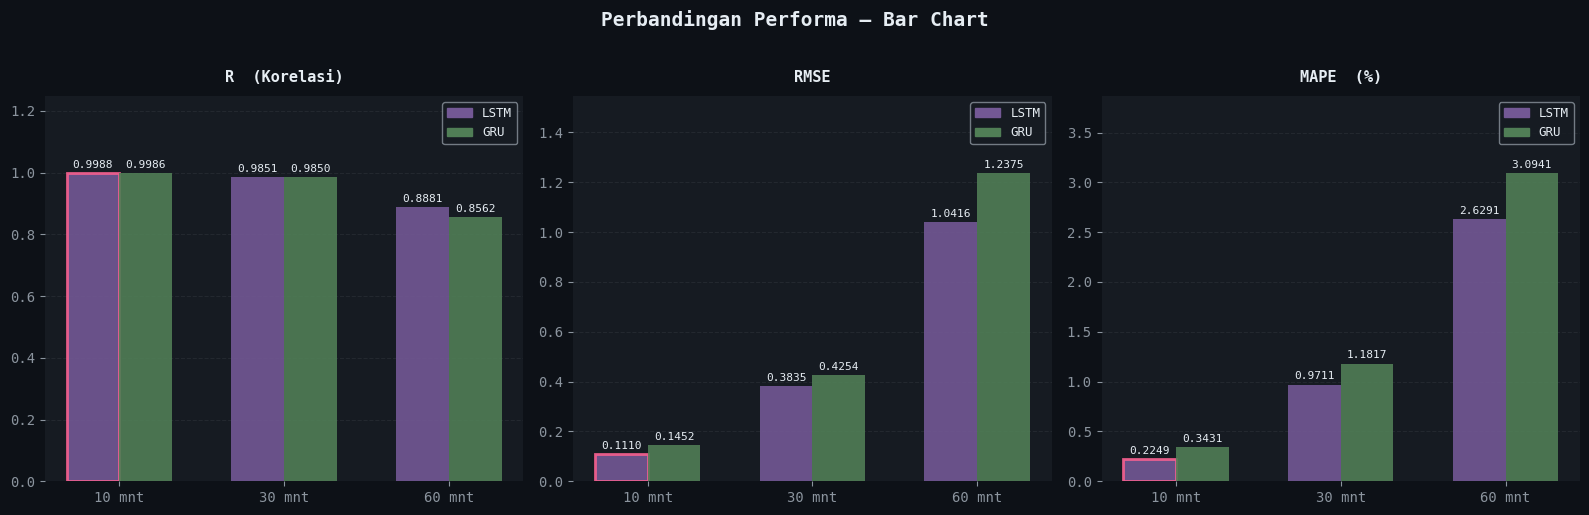

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Perbandingan Performa — Bar Chart', color=TEXT,
             fontsize=14, fontweight='bold', fontfamily='monospace', y=1.02)

metrics = [
    ('R  (Korelasi)', R_lstm,    R_gru,    True),
    ('RMSE',          RMSE_lstm, RMSE_gru, False),
    ('MAPE  (%)',     MAPE_lstm, MAPE_gru, False),
]

for ax, (title, lstm_vals, gru_vals, higher_better) in zip(axes, metrics):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)

    all_vals = lstm_vals + gru_vals
    best_val = max(all_vals) if higher_better else min(all_vals)

    bars1 = ax.bar(x - width/2, lstm_vals, width, color=LSTM_C, alpha=0.9, zorder=3)
    bars2 = ax.bar(x + width/2, gru_vals,  width, color=GRU_C,  alpha=0.9, zorder=3)

    for bars, vals in [(bars1, lstm_vals), (bars2, gru_vals)]:
        for bar, val in zip(bars, vals):
            if val == best_val:
                bar.set_edgecolor(ACCENT)
                bar.set_linewidth(2)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(all_vals)*0.01,
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=8, color=TEXT, fontfamily='monospace')

    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=MUTED)
    ax.tick_params(colors=MUTED)
    ax.set_ylim(0, max(all_vals) * 1.25)
    ax.grid(axis='y', color='#30363D', linestyle='--', alpha=0.5, zorder=0)
    ax.legend(handles=[lstm_patch, gru_patch], facecolor=CARD,
              edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

plt.tight_layout()
plt.show()


### **tren grafik**

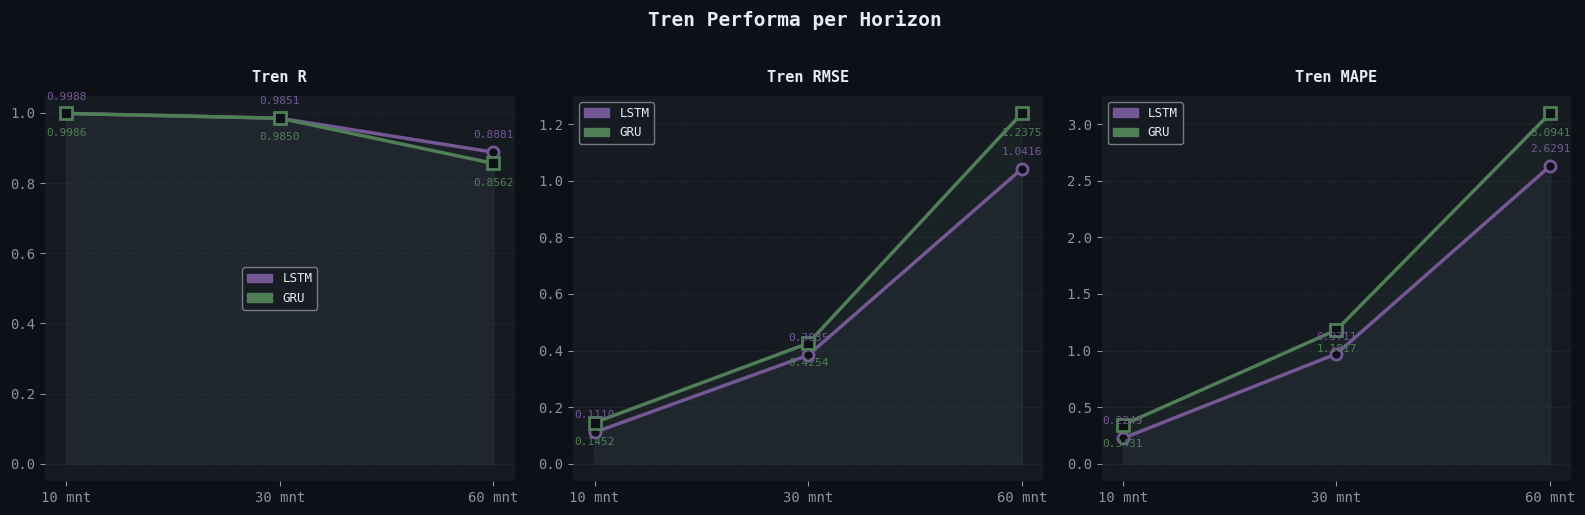

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Tren Performa per Horizon', color=TEXT,
             fontsize=14, fontweight='bold', fontfamily='monospace', y=1.02)

line_metrics = [
    ('Tren R',    R_lstm,    R_gru),
    ('Tren RMSE', RMSE_lstm, RMSE_gru),
    ('Tren MAPE', MAPE_lstm, MAPE_gru),
]

for ax, (title, lstm_vals, gru_vals) in zip(axes, line_metrics):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.plot(labels, lstm_vals, 'o-', color=LSTM_C, lw=2.5,
            markersize=8, markerfacecolor=BG, markeredgewidth=2, label='LSTM')
    ax.plot(labels, gru_vals,  's-', color=GRU_C,  lw=2.5,
            markersize=8, markerfacecolor=BG, markeredgewidth=2, label='GRU')
    ax.fill_between(labels, lstm_vals, alpha=0.08, color=LSTM_C)
    ax.fill_between(labels, gru_vals,  alpha=0.08, color=GRU_C)

    for i, (lv, gv) in enumerate(zip(lstm_vals, gru_vals)):
        ax.annotate(f'{lv:.4f}', (labels[i], lv),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, color=LSTM_C)
        ax.annotate(f'{gv:.4f}', (labels[i], gv),
                    textcoords='offset points', xytext=(0, -16),
                    ha='center', fontsize=8, color=GRU_C)

    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='y', color='#30363D', linestyle='--', alpha=0.5)
    ax.legend(handles=[lstm_patch, gru_patch], facecolor=CARD,
              edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

plt.tight_layout()
plt.show()


### **perbandingan semua model**

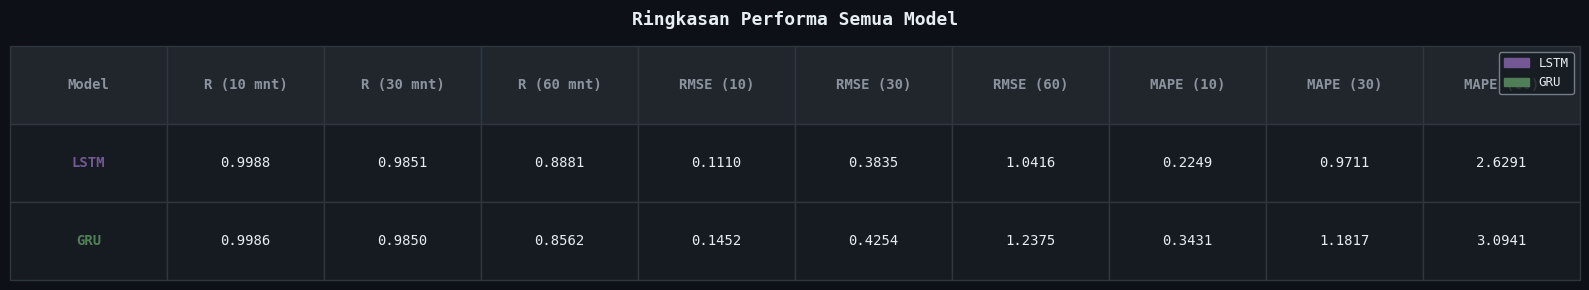

In [21]:
fig, ax = plt.subplots(figsize=(16, 3), facecolor=BG)
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)
ax.axis('off')
ax.set_title('Ringkasan Performa Semua Model', color=TEXT,
             fontsize=13, fontweight='bold', fontfamily='monospace', pad=15)

col_labels = ['Model',
              'R (10 mnt)', 'R (30 mnt)', 'R (60 mnt)',
              'RMSE (10)',  'RMSE (30)',  'RMSE (60)',
              'MAPE (10)',  'MAPE (30)',  'MAPE (60)']
row_lstm = ['LSTM'] + [f'{v:.4f}' for v in R_lstm + RMSE_lstm + MAPE_lstm]
row_gru  = ['GRU']  + [f'{v:.4f}' for v in R_gru  + RMSE_gru  + MAPE_gru]

table = ax.table(cellText=[row_lstm, row_gru], colLabels=col_labels,
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

for (r, c), cell in table.get_celld().items():
    cell.set_facecolor(CARD)
    cell.set_edgecolor('#30363D')
    cell.set_text_props(color=TEXT, fontfamily='monospace')
    if r == 0:
        cell.set_facecolor('#21262D')
        cell.set_text_props(color=MUTED, fontweight='bold')
    if r == 1 and c == 0:
        cell.set_text_props(color=LSTM_C, fontweight='bold')
    if r == 2 and c == 0:
        cell.set_text_props(color=GRU_C, fontweight='bold')

# Legend di tabel
ax.legend(handles=[lstm_patch, gru_patch], loc='upper right',
          facecolor=CARD, edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

plt.tight_layout()
plt.show()
